In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "DesyneMartinez"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW3"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/DesyneMartinez/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/DesyneMartinez/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3


# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: November 21, 2025

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

We are trying to quantify the effect of shoe comfortability based on the factors and material of the shoe.

2.  Specify the outcome variable and how it is measured.

The outcome variable is comfort which is measured on a rating scale between 1 and 10.

3.  Specify the independent variables. What lurking variables may be present?
The independent variables in this experiment are the variables sole_material, Insole_thickness, and Breathability. There could be some lurking variables present such as manufacturer which will depend on the brand of shoe.

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

A full factorial design is used when we are assuming that there may be an interaction between the treatment factors with two levels and in a $2^k$ factorial design we assume the same thing but we extend this k factors with two levels explore the main effects and interactions of multiple factors with a manageable number of experimental runs. In this case a $2^k$ factorial design would be appropriate since we have 3 treatment factors each with two levels.

5.  State the sets of null and alternative hypotheses for this experiment.

- For our main effects:

$$ H_{01}: \alpha_{\text{Standard EVA foam}} = \alpha_{\text{Advanced Gel foam}} = 0 $$
$$ H_{11}: \text{At least one } \alpha_i \neq 0 $$

$$ H_{02}: \beta_{\text{3mm}} = \beta_{\text{6mm}} = 0 $$
$$ H_{12}: \text{At least one } \beta_j \neq 0 $$

$$ H_{03}: \gamma_{\text{Standard woven}} = \gamma_{\text{High performance mesh}} = 0 $$
$$ H_{13}: \text{At least one } \gamma_k \neq 0 $$

- For our two-way interactions:

$$ H_{04}: (\alpha\beta)_{ij} = 0 \text{ for all } i,j $$
$$ H_{14}: \text{At least one } (\alpha\beta)_{ij} \neq 0 $$

$$ H_{05}: (\alpha\gamma)_{ik} = 0 \text{ for all } i,k $$
$$ H_{15}: \text{At least one } (\alpha\gamma)_{ik} \neq 0 $$

$$ H_{06}: (\beta\gamma)_{jk} = 0 \text{ for all } j,k $$
$$ H_{16}: \text{At least one } (\beta\gamma)_{jk} \neq 0 $$

- For our three-way interaction:

$$ H_{07}: (\alpha\beta\gamma)_{ijk} = 0 \text{ for all } i,j,k $$
$$ H_{17}: \text{At least one } (\alpha\beta\gamma)_{ijk} \neq 0 $$





6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [2]:
## Question 6 Code ##
## Import Relevant Packages ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


%pip install openpyxl
## Import Data ##

shoe = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/Shoe Comfort Experiment.xlsx")

## Data Integrity Check ##

print(shoe.info())

## Exploratory Data Analysis ##
## Start with Main Effects ##

## Subscription ##

material_stats = shoe.groupby("sole_material")["comfort"].agg(['mean', 'std'])

print(material_stats)

## App_Offers ##

insole_stats = shoe.groupby("insole_thickness")["comfort"].agg(['mean', 'std'])

print(insole_stats)

## Coaching ##

breathe_stats = shoe.groupby("breathability")["comfort"].agg(['mean', 'std'])

print(breathe_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sole_material     24 non-null     object 
 1   insole_thickness  24 non-null     object 
 2   breathability     24 non-null     object 
 3   comfort           24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 900.0+ bytes
None
                   mean       std
sole_material                    
EVA            7.093638  1.076122
Gel            9.043596  1.545309
                      mean       std
insole_thickness                    
3mm               7.441465  1.387030
6mm               8.695768  1.684642
                   mean       std
breathability                    
Mesh           7.504218  1.272221
Woven          8.633016  1.818369


In [3]:
## sole material x insole thickness ##

material_insole_stats = shoe.groupby(["sole_material", "insole_thickness"])["comfort"].agg(['mean', 'std'])

print(material_insole_stats)

## Sole material x Breathability ##

material_breathe_stats = shoe.groupby(["sole_material", "breathability"])["comfort"].agg(['mean', 'std'])

print(material_breathe_stats)

## breathability x insole thickness ##

breathe_insole_stats = shoe.groupby(["breathability", "insole_thickness"])["comfort"].agg(['mean', 'std'])

print(breathe_insole_stats)

                                    mean       std
sole_material insole_thickness                    
EVA           3mm               6.470980  0.844192
              6mm               7.716295  0.951074
Gel           3mm               8.411950  1.122228
              6mm               9.675242  1.742590
                                 mean       std
sole_material breathability                    
EVA           Mesh           6.700093  1.025948
              Woven          7.487183  1.059911
Gel           Mesh           8.308344  0.977932
              Woven          9.778848  1.731985
                                    mean       std
breathability insole_thickness                    
Mesh          3mm               7.331172  1.350445
              6mm               7.677264  1.290440
Woven         3mm               7.551759  1.542588
              6mm               9.714272  1.445256


In [4]:
## Sole material x insole thickness x breathability ##

material_insole_breathe_stats = shoe.groupby(["sole_material", "insole_thickness", "breathability"])["comfort"].agg(['mean', 'std'])

print(material_insole_breathe_stats)

                                                   mean       std
sole_material insole_thickness breathability                     
EVA           3mm              Mesh            6.368107  1.208337
                               Woven           6.573854  0.538350
              6mm              Mesh            7.032079  0.916897
                               Woven           8.400512  0.127263
Gel           3mm              Mesh            8.294237  0.562753
                               Woven           8.529663  1.670397
              6mm              Mesh            8.322450  1.439997
                               Woven          11.028033  0.166786


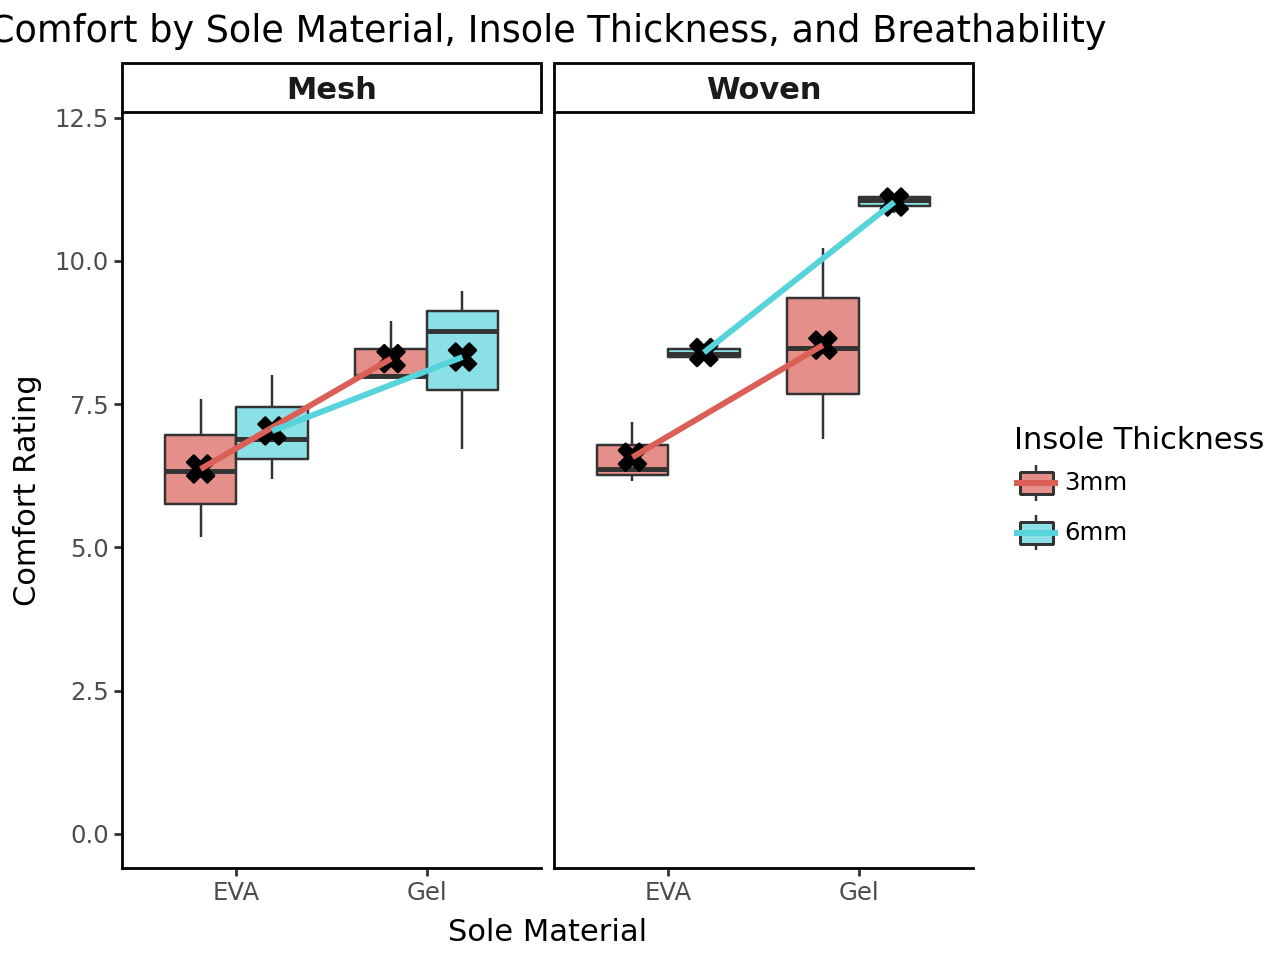

In [5]:
## Install plotnine
#%pip install plotnine
## Import all plotnine functions ##:
from plotnine import *

# Prepare summarized data using the three-way interaction statistics
shoe_means = material_insole_breathe_stats.reset_index()[["sole_material", "insole_thickness", "breathability", "mean"]]

# Define dodge position for aligning points/lines with the boxplots
box_dodge = position_dodge(0.75)

# Build a single faceted plot
p = (
    ggplot(shoe, aes(x='sole_material', y='comfort')) +

    # 1. Boxplot layer (base visualization)
    geom_boxplot(aes(fill='insole_thickness'), alpha=0.7, position=box_dodge) +

    # 2. Mean points (using separate summary data)
    geom_point(
        data=shoe_means,
        mapping=aes(y='mean', group='insole_thickness'),
        shape='X',
        size=5,
        position=box_dodge,
        color='black'
    ) +

    # 3. Mean lines
    geom_line(
        data=shoe_means,
        mapping=aes(y='mean', group='insole_thickness', color='insole_thickness'),
        size=1.2,
        position=box_dodge
    ) +

    # 4. Facet by breathability (two panels side-by-side)
    facet_wrap('~breathability', ncol=2) +

    # 5. Styling and labels
    labs(
        title = "Comfort by Sole Material, Insole Thickness, and Breathability",
        x = "Sole Material",
        y = "Comfort Rating",
        fill = "Insole Thickness",
        color = "Insole Thickness"
    ) +

    theme_classic() +
    theme(
        plot_title = element_text(hjust=0.5),
        strip_text = element_text(size=11, weight='bold')
    ) +

    scale_y_continuous(limits=(0, 12))
)

# Display
p

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


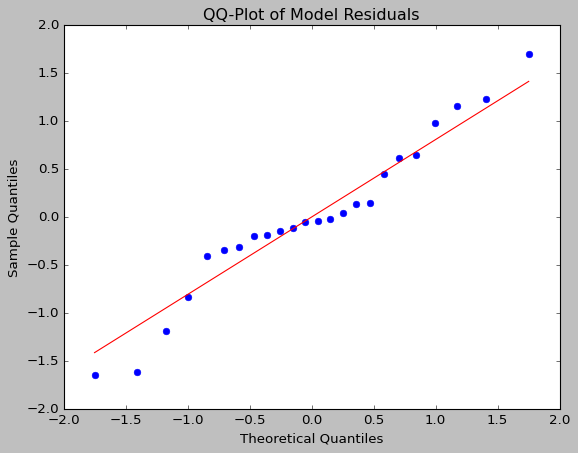

Shapiro-Wilk Test Results:
Statistic: 0.959532741725587
p-value: 0.42910705030991836
Fail to reject the null hypothesis - Residuals are normally distributed.
                                                sum_sq   df         F  \
sole_material                                 5.564969  1.0  5.696617   
insole_thickness                              0.661288  1.0  0.676932   
breathability                                 0.063498  1.0  0.065000   
sole_material:insole_thickness                0.303143  1.0  0.310314   
sole_material:breathability                   0.000661  1.0  0.000676   
insole_thickness:breathability                1.013879  1.0  1.037864   
sole_material:insole_thickness:breathability  0.641055  1.0  0.656220   

                                                PR(>F)     Significance  
sole_material                                 0.029691      Significant  
insole_thickness                              0.422739  Not Significant  
breathability                      

In [7]:
## Question 7 Code ##


## Import Statsmodels ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

## Fit Full Factorial Model ##

model = ols('comfort ~ sole_material*insole_thickness*breathability', data=shoe).fit()

## Parse out model residuals ##

residuals = model.resid

## Test of Normality ##

## QQ-Plot ##

sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

## Shapiro-Wilk Test ##

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
if shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")




8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


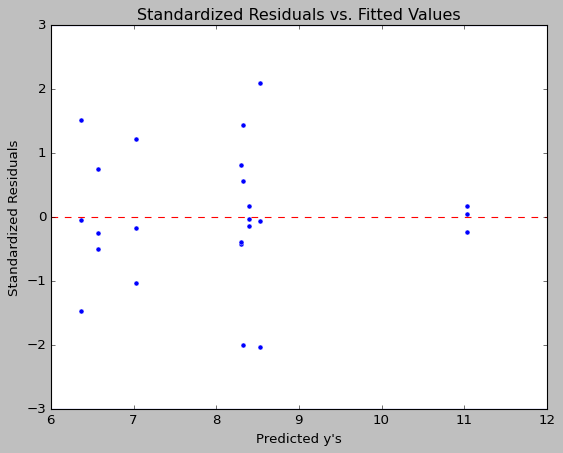

F-statistic: 2.2615166027197584
F p-value: 0.08366429231760693
Fail to reject the null hypothesis - Variances are equal.


In [8]:
## Question 8 Code ##

## Test of Homogeneity of Variance ##

## Scatterplot of Standardized Residuals vs. Fitted Values ##

## Get Standardized Residuals ##

standardized_residuals = model.get_influence().resid_studentized_internal

## Get Fitted Values ##

fitted_values = model.fittedvalues

## Scatterplot ##

## Create the plot ##

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

## B-P Test ##

## Run B-P Test ##

bp_test = het_breuschpagan(residuals, model.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Reject the null hypothesis - Variances are not equal.")
else:
    print("Fail to reject the null hypothesis - Variances are equal.")


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [ ]:
## Question 9 Code ##
## Print ANOVA Table Results ##

anova_table = sm.stats.anova_lm(model, typ=3)

## Add Significance Column ##

anova_table["Significance"] = np.where(anova_table["PR(>F)"] < 0.05, "Significant", "Not Significant")

## Print Table Minus Intercept and Residual Rows ##

print(anova_table.drop(index=["Intercept", "Residual"]))


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [ ]:
## Question 10 Code ##

## Load pingouin ##
import pingouin as pg

## Fit ANOVA with pingouin ##

mod_p = pg.anova(dv='comfort',between=["sole_material","insole_thickness","breathability"],data=shoe,effsize="np2").round(4)

print(mod_p[["Source","np2"]])


11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?



## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

2.  Specify the outcome variable and how it is measured.

3.  Specify the independent variables. What lurking variables may be present?

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

5.  State the sets of null and alternative hypotheses for this experiment.

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [ ]:
## Question 7 Code ##


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


In [ ]:
## Question 8 Code ##


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


In [ ]:
## Question 9 Code ##

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [ ]:
## Question 12 Code ##

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?